In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import cv2
import numpy as np
import subprocess
import os
import pandas as pd
from HairRemoveNet.MaskPredictor import MaskPredictor
from pathlib import Path

PROJECT_DIR = Path.cwd()

I0000 00:00:1786446775.641264   22040 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv("models/HairMaskDetermiNet_metrics.csv", sep=',')

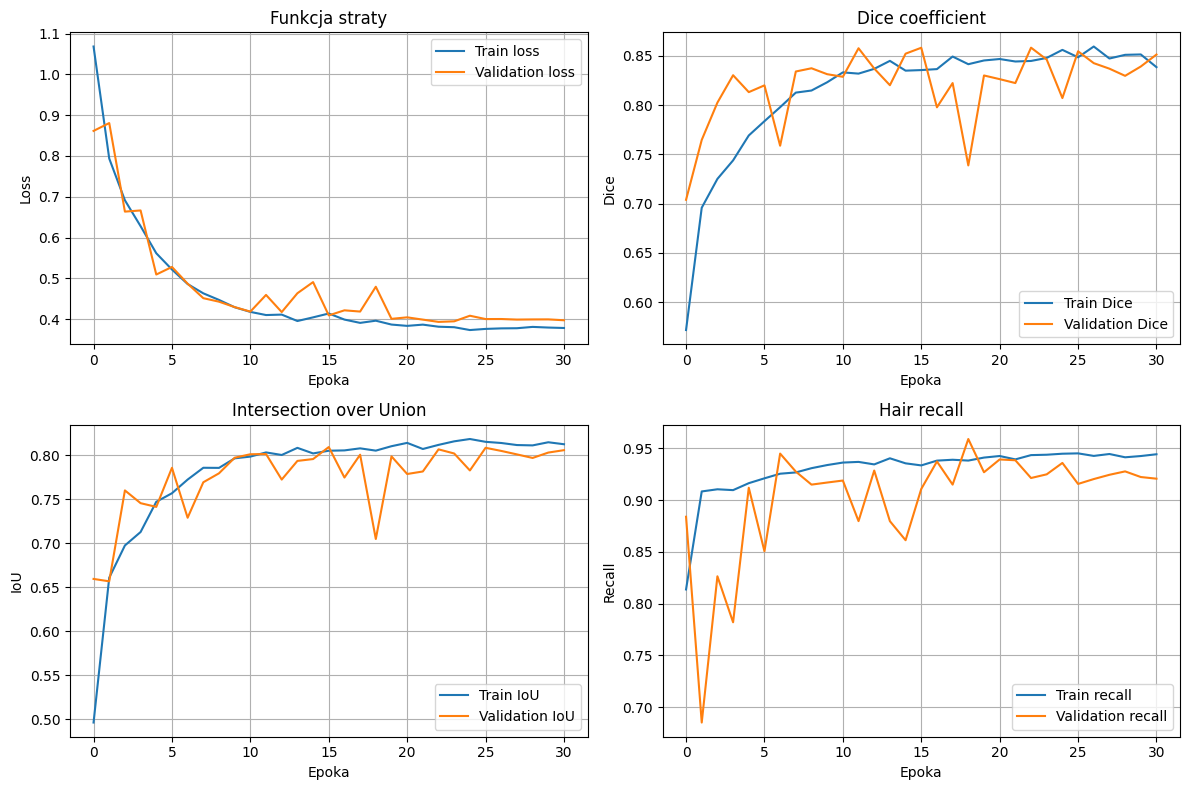

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# 1. Loss
ax[0, 0].plot(df["epoch"], df["loss"], label="Train loss")
ax[0, 0].plot(df["epoch"], df["val_loss"], label="Validation loss")
ax[0, 0].set_title("Funkcja straty")
ax[0, 0].set_xlabel("Epoka")
ax[0, 0].set_ylabel("Loss")
ax[0, 0].legend()
ax[0, 0].grid(True)

# 2. Dice
ax[0, 1].plot(df["epoch"], df["dice_coefficient"], label="Train Dice")
ax[0, 1].plot(df["epoch"], df["val_dice_coefficient"], label="Validation Dice")
ax[0, 1].set_title("Dice coefficient")
ax[0, 1].set_xlabel("Epoka")
ax[0, 1].set_ylabel("Dice")
ax[0, 1].legend()
ax[0, 1].grid(True)

# 3. IoU
ax[1, 0].plot(df["epoch"], df["binary_io_u"], label="Train IoU")
ax[1, 0].plot(df["epoch"], df["val_binary_io_u"], label="Validation IoU")
ax[1, 0].set_title("Intersection over Union")
ax[1, 0].set_xlabel("Epoka")
ax[1, 0].set_ylabel("IoU")
ax[1, 0].legend()
ax[1, 0].grid(True)

# 4. Recall
ax[1, 1].plot(df["epoch"], df["hair_recall"], label="Train recall")
ax[1, 1].plot(df["epoch"], df["val_hair_recall"], label="Validation recall")
ax[1, 1].set_title("Hair recall")
ax[1, 1].set_xlabel("Epoka")
ax[1, 1].set_ylabel("Recall")
ax[1, 1].legend()
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [4]:
generator_input = PROJECT_DIR / "dataset" / "tmp_input"
temporary_output = PROJECT_DIR / "dataset" / "tmp_output"

if not os.path.exists(temporary_output):
    os.makedirs(generator_input, exist_ok=True)
    os.makedirs(temporary_output, exist_ok=True)
    os.system(f'cp "dataset/ROI_ISIC-2017_Test_v2_Data/ISIC_0013216.jpg" {generator_input}')

    subprocess.run(
        [
            str("tools/hair_bezier_generator/build/bin/hair_bezier_generator"),
            "--input-dir", str(generator_input),
            "--output-dir", str(temporary_output),
            "--seed", str(42),
        ],
        check=True,
        stdout=subprocess.DEVNULL,
    )

img_hair_list = []
img_mask_list = []
for img in os.listdir(temporary_output):
    if img.lower().endswith("_hair.png"):
        img_hair_list.append(temporary_output / img)
    if img.lower().endswith("_mask.png"):
        img_mask_list.append(temporary_output / img)

In [5]:
model = MaskPredictor("models/HairMaskDetermiNet.keras")

I0000 00:00:1786446778.077547   22040 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


## Wizualizacja jakości predykcji maski

Zielony oznacza poprawnie wykryte piksele włosów (true positive), a czerwony wszystkie błędy maski: nadmiarowe wykrycia (false positive) oraz pominięte włosy (false negative). Poprawnie rozpoznane tło pozostaje bez koloru, żeby obraz był czytelny.

I0000 00:00:1786446781.647910   22170 service.cc:153] XLA service 0x794860066260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786446781.647949   22170 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1786446781.682032   22170 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786446782.221668   22170 cuda_dnn.cc:461] Loaded cuDNN version 91900
E0000 00:00:1786446788.188365   22170 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1786446793.564518   22170 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


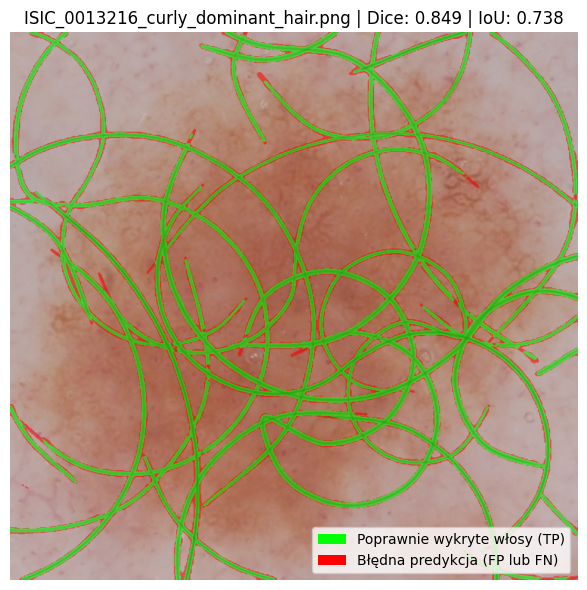

In [6]:
from visualization.MaskPlot import show_mask_prediction, show_real_image_prediction

result = show_mask_prediction(model, img_hair_list[0], threshold=0.5)

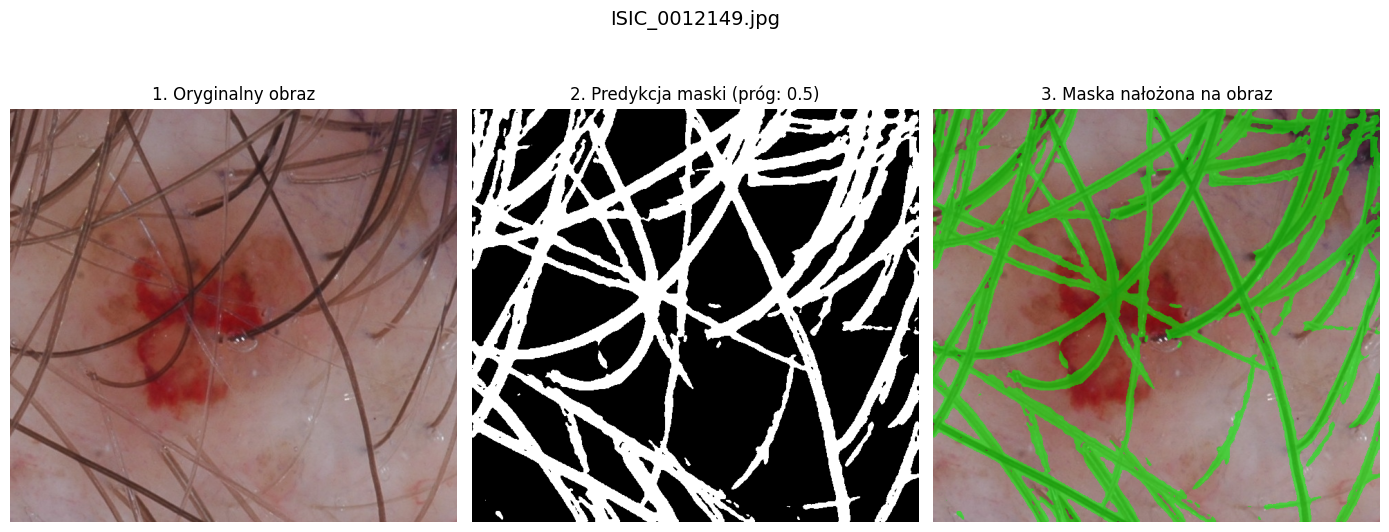

In [7]:
img = PROJECT_DIR / "dataset" / "ROI_ISIC-2017_Test_v2_Data" / "ISIC_0012149.jpg"
result = show_real_image_prediction(model, img, threshold=0.5)